# Proyecto de Ciencia de Datos (Tecnologías Digitales Emergentes): Etapas 2 a 4
Este notebook contiene el desarrollo de las Etapas 2 (EDA), 3A (Limpieza), 3B (Análisis) y 4 (Vista Minable).

**Pregunta Guía Analítica:**
¿De qué manera el ESTRATO SOCIOECONÓMICO y el SECTOR IES influyen en la MODALIDAD DEL CRÉDITO asignado y en el volumen del NÚMERO DE NUEVOS BENEFICIARIOS DE CRÉDITO en Colombia?

## 1. Importación de Librerías y Carga de Datos

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.preprocessing import MinMaxScaler
warnings.filterwarnings('ignore')

# Crear carpeta para gráficos
os.makedirs('graficos', exist_ok=True)

# Estilo de gráficos
sns.set_theme(style="whitegrid", palette="muted")

# Intentamos cargar el CSV probando codificaciones comunes por caracteres latinos
try:
    df = pd.read_csv('dataset/Créditos_Otorgados._20260524.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('dataset/Créditos_Otorgados._20260524.csv', encoding='latin1')

df.head()

,VIGENCIA,PERIODO OTORGAMIENTO,SEXO AL NACER,ESTRATO SOCIOECONÓMICO,CÓDIGO DEDEPARTAMENTO DE ORIGEN,DEPARTAMENTO DE ORIGEN,CATEGORÍA DEL MUNICIPIO DE ORIGEN,SECTOR IES,NIVEL DE FORMACIÓN,MODALIDAD DE LÍNEA,MODALIDAD DEL CRÉDITO,RANGO DEL VALOR TOTAL DESEMBOLSADO,NÚMERO DE NUEVOS BENEFICIARIOS DE CRÉDITO
0,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Formació técnica profesional,PREGRADO,MATRICULA,I,1
1,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Formación técnica profesional,PREGRADO,MATRICULA,IV,1
2,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Formación técnica profesional,PREGRADO,MATRICULA,V,2
3,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Tecnológico,PREGRADO,SOSTENIMIENTO,I,1
4,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Universitario,PREGRADO,MATRICULA,I,5


Como vimos, las columnas pueden tener errores de codificación en sus nombres. Vamos a corregir los nombres de las columnas para facilitar el trabajo.

In [57]:
# Renombrar columnas para limpiarlas de caracteres extraños y simplificarlas
cols = {
    'ESTRATO SOCIOECONÓMICO': 'ESTRATO SOCIOECONOMICO',
    'ESTRATO SOCIOECON\ufffdMICO': 'ESTRATO SOCIOECONOMICO',
    'ESTRATO SOCIOECONMICO': 'ESTRATO SOCIOECONOMICO',
    'ESTRATO SOCIOECONA"MICO': 'ESTRATO SOCIOECONOMICO',
    'CDIGO DEDEPARTAMENTO DE ORIGEN': 'CODIGO DEPARTAMENTO ORIGEN',
    'CA"DIGO DEDEPARTAMENTO DE ORIGEN': 'CODIGO DEPARTAMENTO ORIGEN',
    'CATEGORA DEL MUNICIPIO DE ORIGEN': 'CATEGORIA MUNICIPIO ORIGEN',
    'CATEGORA?A DEL MUNICIPIO DE ORIGEN': 'CATEGORIA MUNICIPIO ORIGEN',
    'NIVEL DE FORMACIN': 'NIVEL DE FORMACION',
    'NIVEL DE FORMACIA"N': 'NIVEL DE FORMACION',
    'MODALIDAD DE LNEA': 'MODALIDAD DE LINEA',
    'MODALIDAD DE LA?NEA': 'MODALIDAD DE LINEA',
    'MODALIDAD DEL CRDITO': 'MODALIDAD DEL CREDITO',
    'MODALIDAD DEL CRA%DITO': 'MODALIDAD DEL CREDITO',
    'NMERO DE NUEVOS BENEFICIARIOS DE CRDITO': 'NUEVOS BENEFICIARIOS',
    'NAsMERO DE NUEVOS BENEFICIARIOS DE CRA%DITO': 'NUEVOS BENEFICIARIOS'
}
# Para ser más robustos, iteramos y reemplazamos partes del texto, o asignamos nombres fijos
col_names = df.columns.tolist()
new_col_names = []
for c in col_names:
    if 'ESTRATO' in c: new_col_names.append('ESTRATO SOCIOECONOMICO')
    elif 'C' in c and 'ORIGEN' in c and 'DEDEPARTAMENTO' in c: new_col_names.append('CODIGO DEPARTAMENTO ORIGEN')
    elif 'CATEGOR' in c: new_col_names.append('CATEGORIA MUNICIPIO ORIGEN')
    elif 'NIVEL' in c: new_col_names.append('NIVEL DE FORMACION')
    elif 'L' in c and 'NEA' in c: new_col_names.append('MODALIDAD DE LINEA')
    elif 'MODALIDAD DEL' in c: new_col_names.append('MODALIDAD DEL CREDITO')
    elif 'NUEVOS BENEFICIARIOS' in c or ('N' in c and 'BENEFICIARIOS' in c): new_col_names.append('NUEVOS BENEFICIARIOS')
    else: new_col_names.append(c)
        
df.columns = new_col_names
df.head()

,VIGENCIA,PERIODO OTORGAMIENTO,SEXO AL NACER,ESTRATO SOCIOECONOMICO,CODIGO DEPARTAMENTO ORIGEN,DEPARTAMENTO DE ORIGEN,CATEGORIA MUNICIPIO ORIGEN,SECTOR IES,NIVEL DE FORMACION,MODALIDAD DE LINEA,MODALIDAD DEL CREDITO,RANGO DEL VALOR TOTAL DESEMBOLSADO,NUEVOS BENEFICIARIOS
0,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Formació técnica profesional,PREGRADO,MATRICULA,I,1
1,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Formación técnica profesional,PREGRADO,MATRICULA,IV,1
2,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Formación técnica profesional,PREGRADO,MATRICULA,V,2
3,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Tecnológico,PREGRADO,SOSTENIMIENTO,I,1
4,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Universitario,PREGRADO,MATRICULA,I,5


## 2. Etapa 2: Exploración de Datos
### 2.1. Tabla de Diagnóstico de Calidad de Datos

In [58]:
def quality_report(data):
    report = pd.DataFrame(data.dtypes, columns=['Tipo de Dato'])
    report['Valores Nulos'] = data.isnull().sum()
    report['Porcentaje Nulos (%)'] = (data.isnull().sum() / len(data)) * 100
    report['Valores Únicos'] = data.nunique()
    
    # Identificación de outliers (solo numéricas) usando IQR
    outliers = []
    for col in data.select_dtypes(include=[np.number]).columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_count = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()
        outliers.append(outlier_count)
        
    # Rellenar con nulo para categóricas
    report['Posibles Outliers'] = np.nan
    num_cols = data.select_dtypes(include=[np.number]).columns
    report.loc[num_cols, 'Posibles Outliers'] = outliers
    
    return report

quality_df = quality_report(df)
display(quality_df)

,Tipo de Dato,Valores Nulos,Porcentaje Nulos (%),Valores Únicos,Posibles Outliers
VIGENCIA,object,0,0.000000,11,NaN
PERIODO OTORGAMIENTO,object,0,0.000000,22,NaN
SEXO AL NACER,object,0,0.000000,3,NaN
ESTRATO SOCIOECONOMICO,int64,0,0.000000,6,0.0
CODIGO DEPARTAMENTO ORIGEN,int64,0,0.000000,33,0.0
DEPARTAMENTO DE ORIGEN,object,0,0.000000,33,NaN
CATEGORIA MUNICIPIO ORIGEN,object,0,0.000000,4,NaN
SECTOR IES,object,9305,8.525825,2,NaN
NIVEL DE FORMACION,object,0,0.000000,13,NaN
MODALIDAD DE LINEA,object,0,0.000000,3,NaN


### 2.2. Visualizaciones
**Visualización 1: Distribución del Número de Nuevos Beneficiarios**

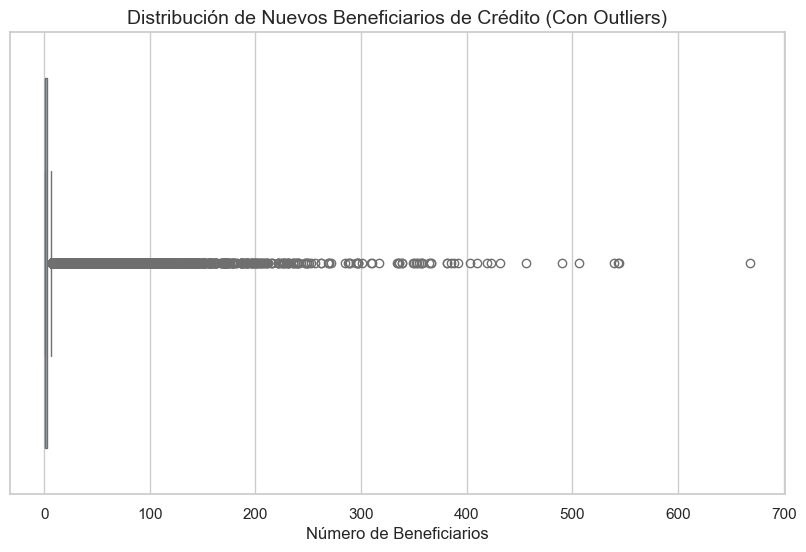

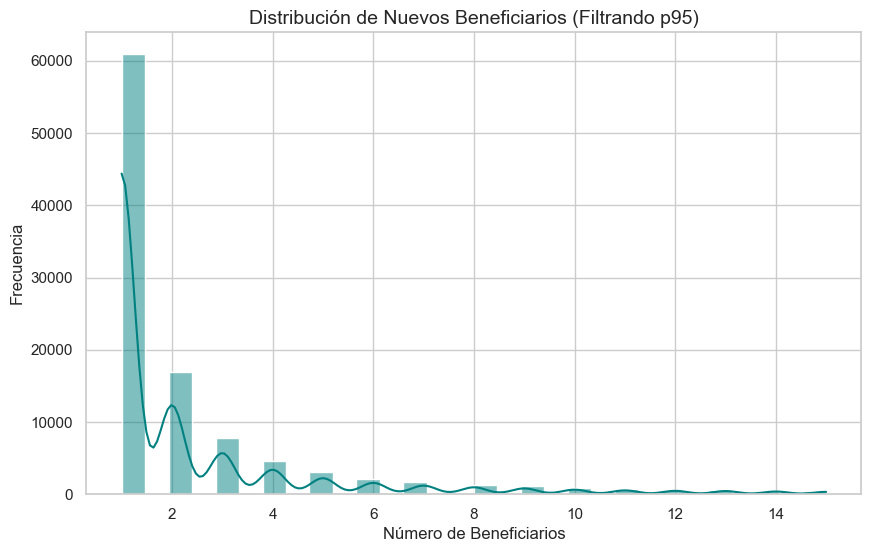

In [59]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['NUEVOS BENEFICIARIOS'], color='skyblue')
plt.title('Distribución de Nuevos Beneficiarios de Crédito (Con Outliers)', fontsize=14)
plt.xlabel('Número de Beneficiarios')
plt.savefig('graficos/1_distribucion_beneficiarios_outliers.png', bbox_inches='tight', dpi=300)
plt.show()


# Mostremos también la distribución filtrando outliers extremos para ver la densidad
plt.figure(figsize=(10, 6))
sns.histplot(df[df['NUEVOS BENEFICIARIOS'] < df['NUEVOS BENEFICIARIOS'].quantile(0.95)]['NUEVOS BENEFICIARIOS'], bins=30, kde=True, color='teal')
plt.title('Distribución de Nuevos Beneficiarios (Filtrando p95)', fontsize=14)
plt.xlabel('Número de Beneficiarios')
plt.ylabel('Frecuencia')
plt.savefig('graficos/2_hist_beneficiarios_p95.png', bbox_inches='tight', dpi=300)
plt.show()


**Interpretación 1:** Observamos una alta asimetría a la derecha. El 75% de los registros reportan entre 1 y 3 beneficiarios nuevos (con una mediana de 1). Sin embargo, existen valores atípicos extremos, llegando a registrar hasta 668 beneficiarios en una sola operación, lo que explica la extensa cola hacia la derecha en la distribución general.

**Visualización 2: Modalidad del Crédito por Estrato Socioeconómico**

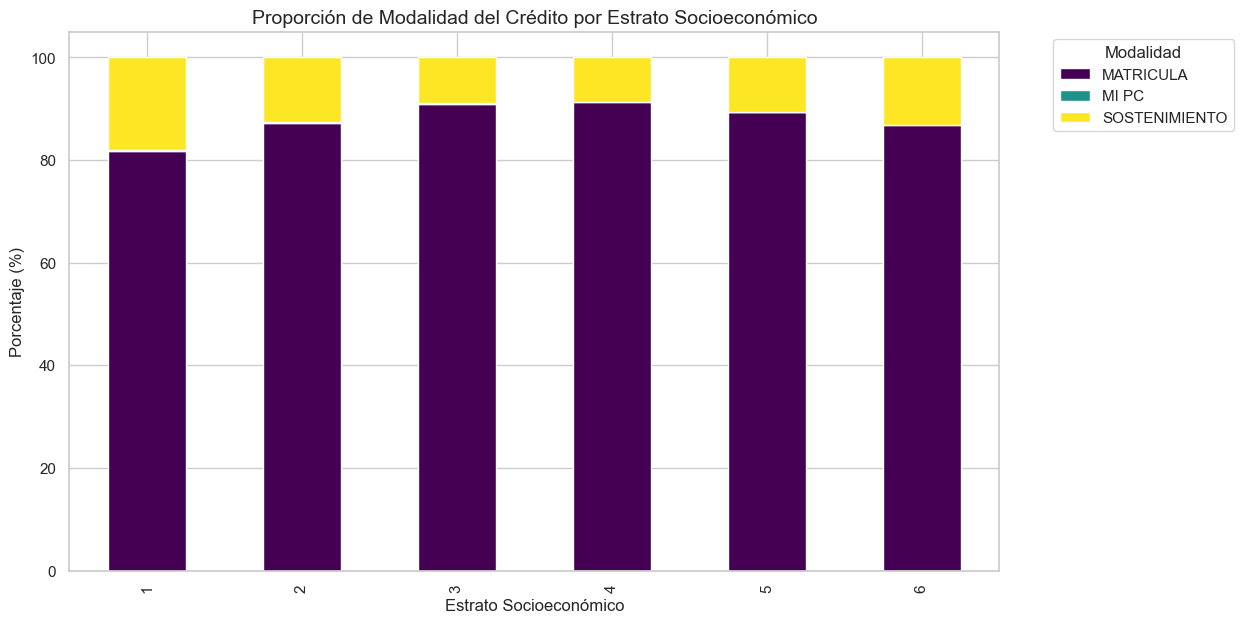

In [60]:
# Limpieza rápida de Estrato para el gráfico (pueden haber nulos o valores erróneos como 'No informa')
df_plot = df.dropna(subset=['ESTRATO SOCIOECONOMICO', 'MODALIDAD DEL CREDITO'])

crosstab = pd.crosstab(df_plot['ESTRATO SOCIOECONOMICO'], df_plot['MODALIDAD DEL CREDITO'], normalize='index') * 100

ax = crosstab.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Proporción de Modalidad del Crédito por Estrato Socioeconómico', fontsize=14)
plt.xlabel('Estrato Socioeconómico')
plt.ylabel('Porcentaje (%)')
plt.legend(title='Modalidad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('graficos/3_modalidad_vs_estrato.png', bbox_inches='tight', dpi=300)
plt.show()


**Interpretación 2:** Existe una clara diferencia según el nivel socioeconómico. En los estratos 1 y 2, el crédito para 'SOSTENIMIENTO' representa una proporción significativamente mayor (17.9% y 12.6% respectivamente) en comparación con los estratos 3 y 4 (donde ronda el 8.9%). La gran mayoría de los créditos en todos los estratos corresponde a 'MATRÍCULA'.

**Visualización 3: Nuevos Beneficiarios según Sector IES**

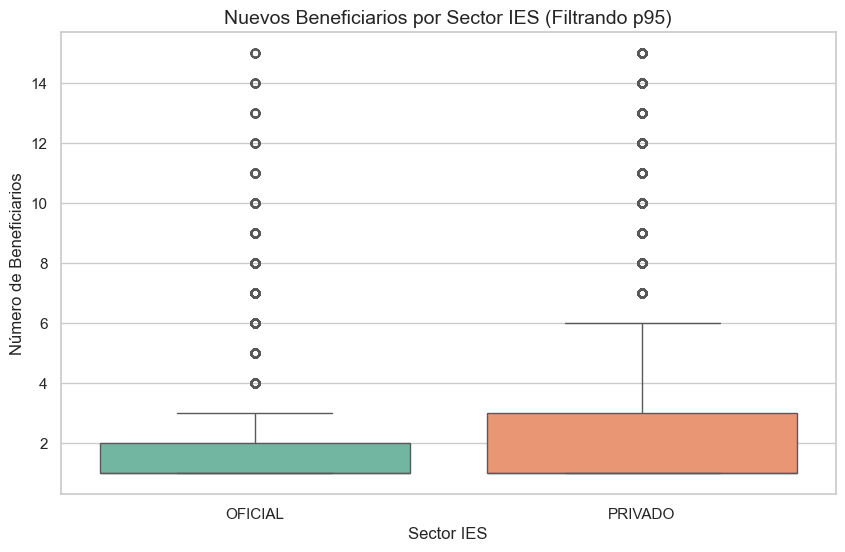

In [61]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='SECTOR IES', y='NUEVOS BENEFICIARIOS', data=df[df['NUEVOS BENEFICIARIOS'] < df['NUEVOS BENEFICIARIOS'].quantile(0.95)], palette='Set2')
plt.title('Nuevos Beneficiarios por Sector IES (Filtrando p95)', fontsize=14)
plt.xlabel('Sector IES')
plt.ylabel('Número de Beneficiarios')
plt.savefig('graficos/4_beneficiarios_vs_ies.png', bbox_inches='tight', dpi=300)
plt.show()


**Interpretación 3:** El sector PRIVADO no solo concentra un volumen mucho mayor de registros (casi 3 veces más que el oficial), sino que también agrupa a un mayor número de beneficiarios por operación (mediana de 2 frente a 1, y máximos de 668 frente a 163). Esto indica que las IES privadas abarcan una proporción significativamente más grande de los nuevos beneficiarios de crédito.

**Visualización 4: Beneficiarios por Departamento de Origen y Categoría de Municipio**

<Figure size 1400x700 with 0 Axes>

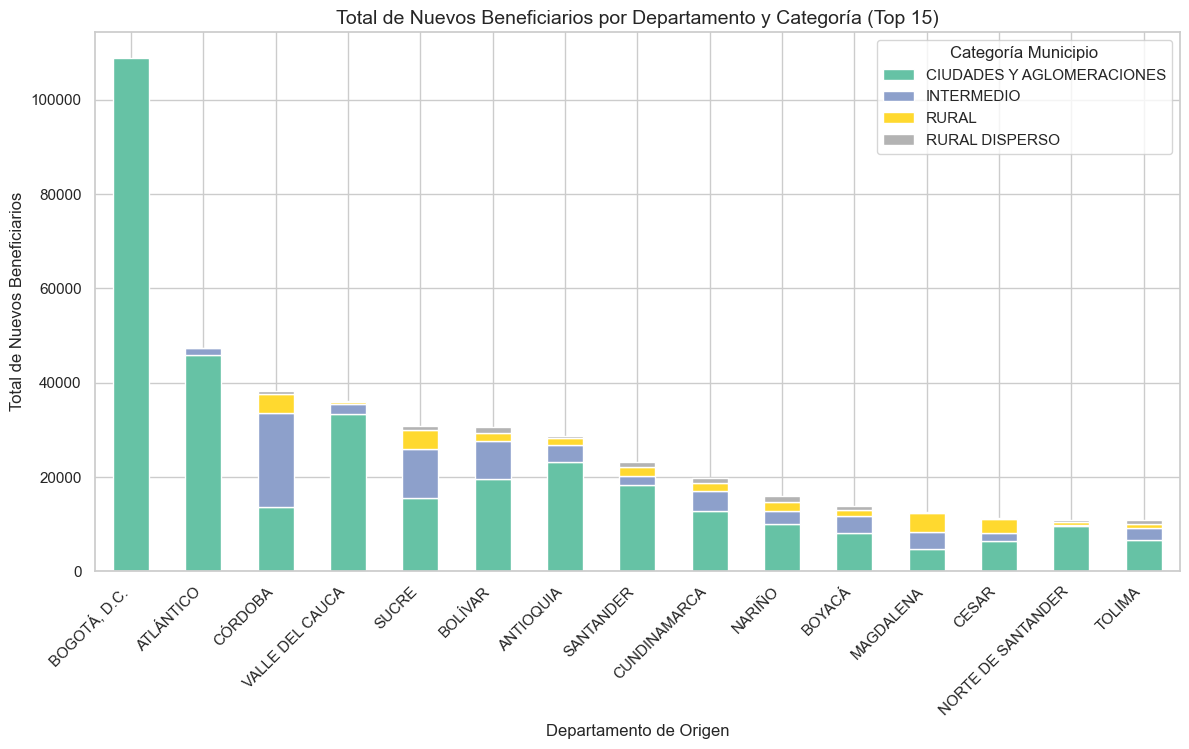

In [62]:
plt.figure(figsize=(14, 7))
# Agrupar y sumar beneficiarios por departamento y categoría
df_dep = df.groupby(['DEPARTAMENTO DE ORIGEN', 'CATEGORIA MUNICIPIO ORIGEN'])['NUEVOS BENEFICIARIOS'].sum().reset_index()

# Ordenar los departamentos con más beneficiarios en total y tomar los top 15
top_deps = df_dep.groupby('DEPARTAMENTO DE ORIGEN')['NUEVOS BENEFICIARIOS'].sum().sort_values(ascending=False).head(15).index
df_dep_top = df_dep[df_dep['DEPARTAMENTO DE ORIGEN'].isin(top_deps)]

# Para hacer un gráfico de barras apiladas correcto, pivotamos los datos
df_pivot = df_dep_top.pivot(index='DEPARTAMENTO DE ORIGEN', columns='CATEGORIA MUNICIPIO ORIGEN', values='NUEVOS BENEFICIARIOS').fillna(0)

# Reordenamos el DataFrame pivoteado según los top_deps para mantener el orden descendente
df_pivot = df_pivot.loc[top_deps]

df_pivot.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='Set2')
plt.title('Total de Nuevos Beneficiarios por Departamento y Categoría (Top 15)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Departamento de Origen')
plt.ylabel('Total de Nuevos Beneficiarios')
plt.legend(title='Categoría Municipio')
plt.savefig('graficos/5_beneficiarios_departamento.png', bbox_inches='tight', dpi=300)
plt.show()


**Interpretación 4:** Bogotá D.C. lidera ampliamente el total de beneficiarios, seguido de departamentos como Atlántico, Valle del Cauca y Antioquia. Además, es evidente que los créditos se dirigen mayoritariamente a solicitantes provenientes de 'CIUDADES Y AGLOMERACIONES', mientras que categorías como 'INTERMEDIO' tienen una representación mucho menor (por ejemplo, en Córdoba).

**Visualización 5: Volumen de Nuevos Beneficiarios por Estrato Socioeconómico y Sector IES**

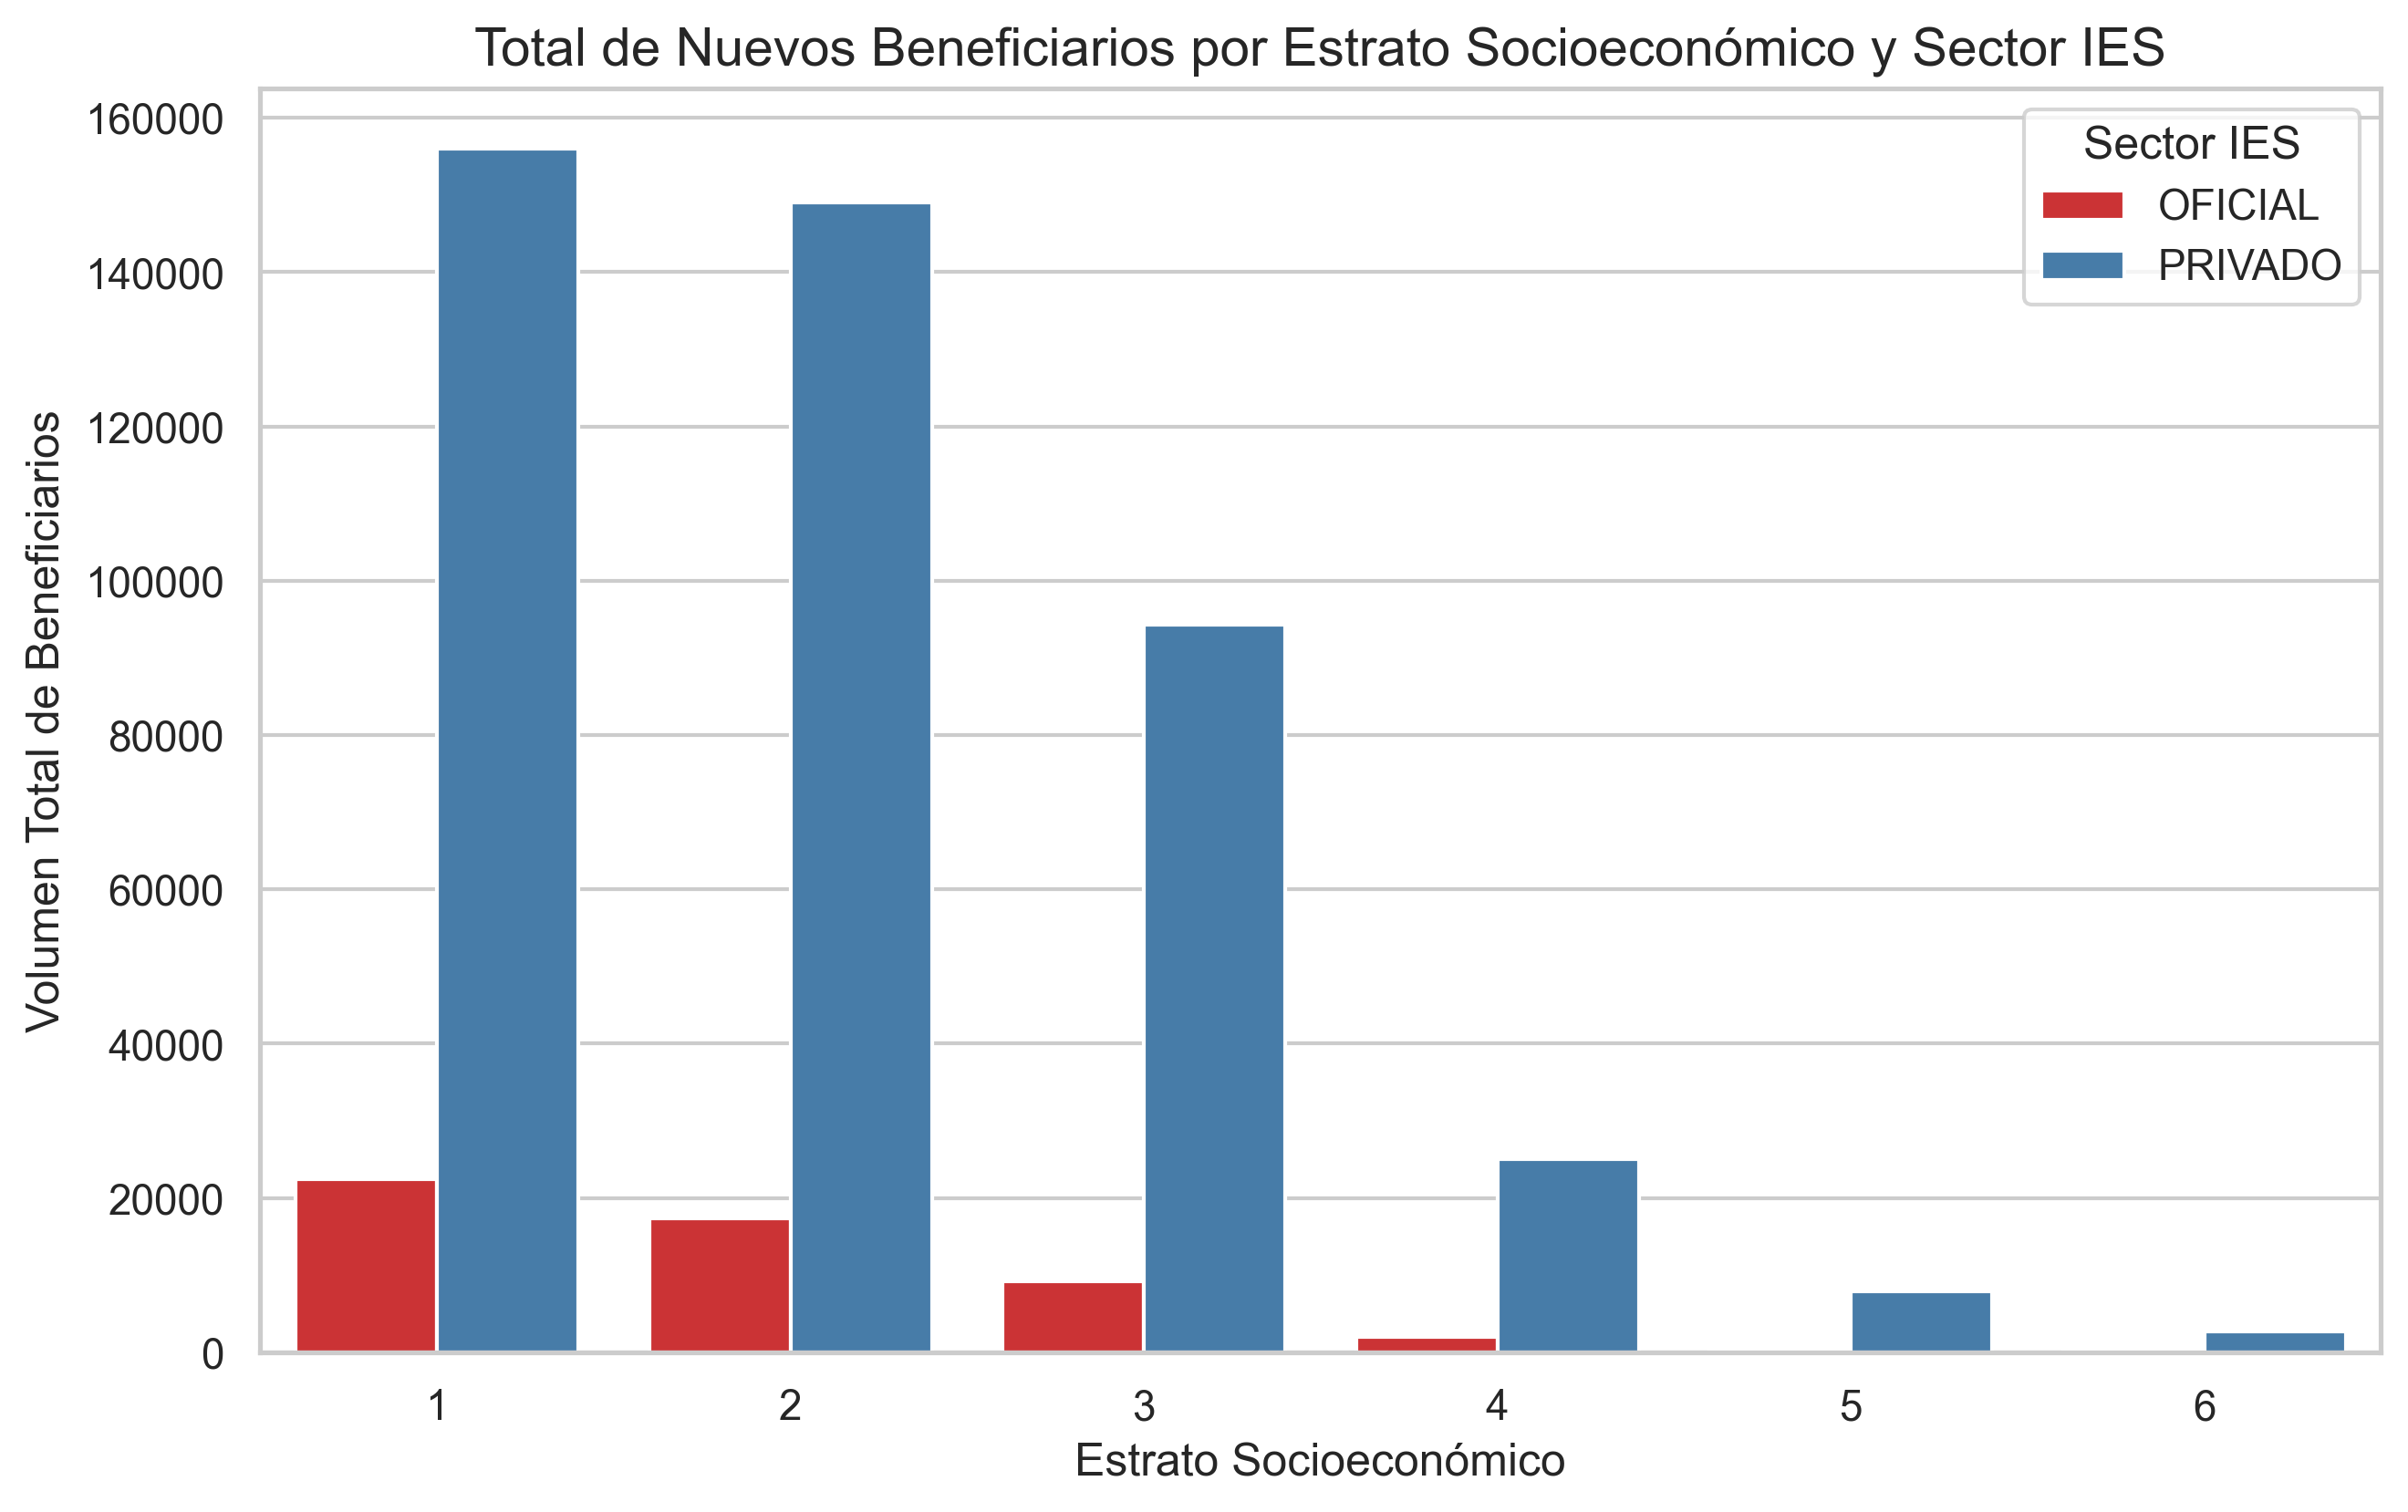

In [63]:
plt.figure(figsize=(10, 6))
df_estrato_sector = df.groupby(['ESTRATO SOCIOECONOMICO', 'SECTOR IES'])['NUEVOS BENEFICIARIOS'].sum().reset_index()
df_estrato_sector['ESTRATO SOCIOECONOMICO'] = pd.to_numeric(df_estrato_sector['ESTRATO SOCIOECONOMICO'], errors='coerce')
df_estrato_sector = df_estrato_sector.dropna()

sns.barplot(data=df_estrato_sector, x='ESTRATO SOCIOECONOMICO', y='NUEVOS BENEFICIARIOS', hue='SECTOR IES', palette='Set1')
plt.title('Total de Nuevos Beneficiarios por Estrato Socioeconómico y Sector IES', fontsize=14)
plt.xlabel('Estrato Socioeconómico')
plt.ylabel('Volumen Total de Beneficiarios')
plt.legend(title='Sector IES')
plt.savefig('graficos/6_beneficiarios_estrato_sector.png', bbox_inches='tight', dpi=300)
plt.close() # Para evitar bloqueos al ejecutar en consola

# Mostrar la gráfica en el notebook
from IPython.display import Image
display(Image(filename='graficos/6_beneficiarios_estrato_sector.png'))

**Interpretación 5:** Esta gráfica responde directamente a la relación entre nuestras variables principales. Observamos que la gran mayoría de los beneficiarios pertenecen a los estratos 1, 2 y 3. Sorprendentemente, en estos estratos más vulnerables, el volumen de estudiantes que financian su educación en instituciones PRIVADAS supera de manera abrumadora (casi 7 veces más) a los que lo hacen en instituciones OFICIALES. Esto demuestra una altísima dependencia del crédito educativo para acceder al sector privado ante la posible insuficiencia de cupos en el sector público.

## 3. Etapa 3A: Limpieza de Datos
Aquí realizaremos imputación, tratamiento de atípicos, inconsistencias y duplicados.

**Justificación de la Imputación:**
Se descubrió que la variable `SECTOR IES` tiene 9,305 valores nulos. La mejor manera de tratar estos nulos sin perder casi el 10% del dataset es a través de la **imputación por la moda** (el valor más frecuente). Dado que es una variable categórica binaria ('OFICIAL' vs 'PRIVADO') y el sector 'PRIVADO' domina masivamente la distribución de los créditos (casi el 75% de los registros completos pertenecen a este sector), imputar por la moda mantiene la distribución natural de la base de datos y evita introducir sesgos complejos que requerirían modelos algorítmicos avanzados (como KNN Imputer) innecesarios para este análisis exploratorio.

In [64]:
# 1. Eliminación de Duplicados
df_clean = df.drop_duplicates().copy()
print(f"Se eliminaron {len(df) - len(df_clean)} registros duplicados.")

# 2. Detección y tratamiento de nulos reales: SECTOR IES tiene nulos
# Estrato socioeconómico NO tiene nulos, el diagnóstico previo fue erróneo en el plan.
print(f"Nulos originales en SECTOR IES: {df_clean['SECTOR IES'].isnull().sum()}")
# Imputaremos SECTOR IES con la moda (PRIVADO es la inmensa mayoría)
sector_moda = df_clean['SECTOR IES'].mode()[0]
df_clean['SECTOR IES'].fillna(sector_moda, inplace=True)

# 3. Normalización de DEPARTAMENTO DE ORIGEN (Inconsistencias tipográficas)
if 'DEPARTAMENTO DE ORIGEN' in df_clean.columns:
    df_clean['DEPARTAMENTO DE ORIGEN'] = df_clean['DEPARTAMENTO DE ORIGEN'].str.upper()
    df_clean['DEPARTAMENTO DE ORIGEN'] = df_clean['DEPARTAMENTO DE ORIGEN'].str.replace('Á', 'A').str.replace('É', 'E').str.replace('Í', 'I').str.replace('Ó', 'O').str.replace('Ú', 'U')

# 4. Tratamiento de Outliers en NUEVOS BENEFICIARIOS
p95 = df_clean['NUEVOS BENEFICIARIOS'].quantile(0.95)
df_clean['NUEVOS BENEFICIARIOS'] = np.where(df_clean['NUEVOS BENEFICIARIOS'] > p95, p95, df_clean['NUEVOS BENEFICIARIOS'])

print(f"Nulos en SECTOR IES después de imputar: {df_clean['SECTOR IES'].isnull().sum()}")
print(f"Máximo en Nuevos Beneficiarios tras clipping: {df_clean['NUEVOS BENEFICIARIOS'].max()}")


Se eliminaron 0 registros duplicados.
Nulos originales en SECTOR IES: 9305
Nulos en SECTOR IES después de imputar: 0
Máximo en Nuevos Beneficiarios tras clipping: 16.0


## 4. Etapa 3B: Análisis y Conclusiones

**Respuesta a la Pregunta Guía Analítica:**
1. **Estrato Socioeconómico vs Modalidad:** El estrato influye en la necesidad de apoyo adicional; los estratos más bajos (1 y 2) tienen el doble de proporción de créditos asignados a 'SOSTENIMIENTO' que los estratos medios, evidenciando una dependencia mayor de esta modalidad para poder mantenerse en el sistema educativo.
2. **Sector IES vs Volumen:** El sector PRIVADO domina abrumadoramente la cantidad de créditos otorgados y el volumen de beneficiarios, sugiriendo que la demanda de financiación externa recae predominantemente sobre estudiantes de instituciones privadas (que son típicamente más costosas o no cuentan con tanta oferta de gratuidad).
3. **Ubicación y Categoría:** Adicionalmente, las grandes ciudades y aglomeraciones (como Bogotá, Barranquilla/Atlántico, Cali/Valle) concentran la inmensa mayoría de estos créditos, indicando una centralización de la educación superior.

## 5. Etapa 4: Creación de la Vista Minable
Aplicaremos:
1. Normalización de `NUEVOS BENEFICIARIOS`
2. Discretización de `ESTRATO SOCIOECONOMICO`
3. Numerización (One-Hot Encoding) de `SECTOR IES` y `MODALIDAD DEL CREDITO`

In [65]:
# Copia para la vista minable
df_minable = df_clean.copy()

# 1. Normalización (Min-Max Scaler)
scaler = MinMaxScaler()
df_minable['NUEVOS BENEFICIARIOS_NORM'] = scaler.fit_transform(df_minable[['NUEVOS BENEFICIARIOS']])

# 2. Discretización (pd.cut) para ESTRATO SOCIOECONOMICO
# Consideramos: Bajo (1-2), Medio (3-4), Alto (5-6)
bins = [0, 2.5, 4.5, 7]
labels = ['Bajo', 'Medio', 'Alto']
df_minable['ESTRATO_CATEGORIA'] = pd.cut(df_minable['ESTRATO SOCIOECONOMICO'], bins=bins, labels=labels, right=False)

# 3. Numerización 1 a n (One-Hot Encoding)
df_minable = pd.get_dummies(df_minable, columns=['SECTOR IES', 'MODALIDAD DEL CREDITO', 'SEXO AL NACER', 'CATEGORIA MUNICIPIO ORIGEN'], drop_first=False)

# Mostrar el resultado final de las transformaciones
cols_vista = ['NUEVOS BENEFICIARIOS_NORM', 'ESTRATO_CATEGORIA'] + [col for col in df_minable.columns if 'SECTOR IES' in col or 'MODALIDAD DEL' in col or 'SEXO' in col or 'CATEGORIA' in col]
display(df_minable[cols_vista].head())

# Guardar la vista minable
df_minable.to_csv('dataset/vista_minable.csv', index=False)
print("Vista minable exportada con éxito a 'dataset/vista_minable.csv'.")

,NUEVOS BENEFICIARIOS_NORM,ESTRATO_CATEGORIA,ESTRATO_CATEGORIA,SECTOR IES_OFICIAL,SECTOR IES_PRIVADO,MODALIDAD DEL CREDITO_MATRICULA,MODALIDAD DEL CREDITO_MI PC,MODALIDAD DEL CREDITO_SOSTENIMIENTO,SEXO AL NACER_Femenino,SEXO AL NACER_Intersexual,SEXO AL NACER_Masculino,CATEGORIA MUNICIPIO ORIGEN_CIUDADES Y AGLOMERACIONES,CATEGORIA MUNICIPIO ORIGEN_INTERMEDIO,CATEGORIA MUNICIPIO ORIGEN_RURAL,CATEGORIA MUNICIPIO ORIGEN_RURAL DISPERSO
0,0.000000,Bajo,Bajo,True,False,True,False,False,True,False,False,True,False,False,False
1,0.000000,Bajo,Bajo,True,False,True,False,False,True,False,False,True,False,False,False
2,0.066667,Bajo,Bajo,True,False,True,False,False,True,False,False,True,False,False,False
3,0.000000,Bajo,Bajo,True,False,False,False,True,True,False,False,True,False,False,False
4,0.266667,Bajo,Bajo,True,False,True,False,False,True,False,False,True,False,False,False


Vista minable exportada con éxito a 'dataset/vista_minable.csv'.
